In [5]:
%pip install -q torch torchvision pillow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

In [7]:
# Mirrors license_plates_vae/draw_plates_rectangle2.py so both experiments use identical settings
IMG_HEIGHT   = 32
IMG_WIDTH    = 96
IMG_CHANNELS = 1      # grayscale
BATCH_SIZE   = 32
EPOCHS       = 100
LR           = 1e-4
ADAM_BETA1   = 0.5    # matches DRAW optimizer (beta1=0.5)
GRAD_CLIP    = 5.0    # matches DRAW gradient clipping (clip_by_global_norm=5.0)
KL_WEIGHT    = 0.1    # matches DRAW kl_weight
SEED         = 42
LATENT_DIM   = 64     # matches DRAW z_size
HIDDEN_DIMS  = [32, 64, 128]

# Same data used by the DRAW model
DATA_DIR = os.path.join('./', 'draw_plate_data_prepared_combined')

torch.manual_seed(SEED)
print(f'Image size: {IMG_CHANNELS}×{IMG_HEIGHT}×{IMG_WIDTH}')

Image size: 1×32×96


## Dataset

Real grayscale licence plates loaded from the same `.npy` files used by the DRAW model in
`license_plates_vae/draw_plate_data_prepared_combined/`. The pre-split train/val sets
ensure both models see exactly the same images.
Images are `1 × 32 × 96` (C × H × W), pixel values normalised to **[0, 1]**.
Dataset sizes: **1497 train / 187 val** (from the combined 1872-image corpus).

Train: 1497 | Val: 187
Batch shape: torch.Size([32, 1, 32, 96])  (B × C × H × W)


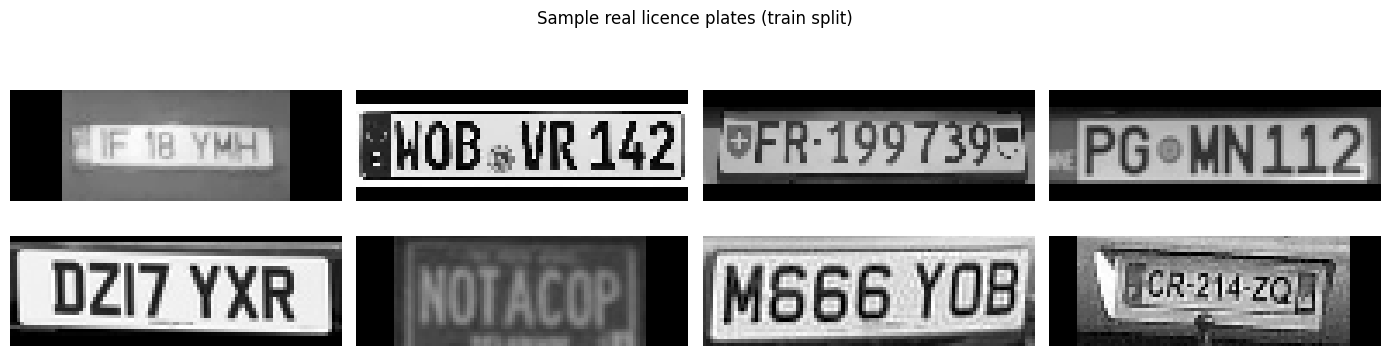

In [8]:
class LicensePlateNPYDataset(Dataset):
    """Loads pre-processed 96×32 licence plate images from a .npy file."""
    def __init__(self, npy_path):
        data = np.load(npy_path).astype(np.float32)
        if data.max() > 1.0:
            data = data / 255.0
        # DRAW saves images flat: (N, H*W); reshape to (N, H, W)
        if data.ndim == 2:
            data = data.reshape(-1, IMG_HEIGHT, IMG_WIDTH)
        self.data = torch.from_numpy(data).unsqueeze(1)  # (N, 1, H, W)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


train_ds = LicensePlateNPYDataset(os.path.join(DATA_DIR, 'train_96x32.npy'))
val_ds   = LicensePlateNPYDataset(os.path.join(DATA_DIR, 'val_96x32.npy'))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample_batch = next(iter(train_loader))
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Batch shape: {sample_batch.shape}  (B × C × H × W)')

fig, axes = plt.subplots(2, 4, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_batch[i].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.suptitle('Sample real licence plates (train split)')
plt.tight_layout()
plt.show()

## VAE Model, Loss Functions

In [9]:
class VAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_dims, latent_dim, img_height, img_width):
        super().__init__()
        layers = []
        ch = in_channels
        for h in hidden_dims:
            layers += [
                nn.Conv2d(ch, h, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(h),
                nn.ReLU(inplace=True),
            ]
            ch = h
        self.convs = nn.Sequential(*layers)
        scale = 2 ** len(hidden_dims)
        flat_size = hidden_dims[-1] * (img_height // scale) * (img_width // scale)
        self.fc_mu     = nn.Linear(flat_size, latent_dim)
        self.fc_logvar = nn.Linear(flat_size, latent_dim)

    def forward(self, x):
        h = self.convs(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)


class VAEDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims, out_channels, img_height, img_width):
        super().__init__()
        scale = 2 ** len(hidden_dims)
        self._flat_h = img_height // scale
        self._flat_w = img_width  // scale
        self._first_ch = hidden_dims[-1]
        flat_size = hidden_dims[-1] * self._flat_h * self._flat_w
        self.fc = nn.Linear(latent_dim, flat_size)
        layers = []
        rev = list(reversed(hidden_dims))
        for i in range(len(rev) - 1):
            layers += [
                nn.ConvTranspose2d(rev[i], rev[i+1], kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(rev[i+1]),
                nn.ReLU(inplace=True),
            ]
        layers += [
            nn.ConvTranspose2d(rev[-1], out_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        ]
        self.deconvs = nn.Sequential(*layers)

    def forward(self, z):
        h = self.fc(z).view(z.size(0), self._first_ch, self._flat_h, self._flat_w)
        return self.deconvs(h)


class VAE(nn.Module):
    def __init__(self, img_channels=1, img_height=32, img_width=96,
                 hidden_dims=None, latent_dim=64):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [32, 64, 128]
        self.latent_dim = latent_dim
        self.encoder = VAEEncoder(img_channels, hidden_dims, latent_dim, img_height, img_width)
        self.decoder = VAEDecoder(latent_dim, hidden_dims, img_channels, img_height, img_width)

    def reparameterise(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterise(mu, logvar)
        return self.decoder(z), mu, logvar

    def sample(self, num_samples, device):
        z = torch.randn(num_samples, self.latent_dim, device=device)
        return self.decoder(z)


def vae_loss(x, x_hat, mu, logvar, kl_weight=KL_WEIGHT):
    """Returns (total, recon, kl) — all scalar tensors.

    KL formulation matches DRAW: sum over latent dims, mean over batch.
    Equivalent to draw_plates_rectangle2.py: 0.5*(mu^2+sigma^2-2*log_sigma-1)
    which in logvar notation is 0.5*(mu^2 + exp(logvar) - logvar - 1).
    """
    recon = F.binary_cross_entropy(x_hat, x, reduction='sum') / x.size(0)
    kl    = 0.5 * (mu.pow(2) + logvar.exp() - logvar - 1).sum(dim=1).mean()
    return recon + kl_weight * kl, recon, kl

## Training

Using device: cuda
Epoch  10/100  train: 1424.7291  val: 1435.3546
Epoch  20/100  train: 1379.1459  val: 1406.6413
Epoch  30/100  train: 1354.1211  val: 1375.5211
Epoch  40/100  train: 1335.4288  val: 1360.9771
Epoch  50/100  train: 1323.8108  val: 1350.6827
Epoch  60/100  train: 1312.1432  val: 1342.1490
Epoch  70/100  train: 1304.7050  val: 1336.3303
Epoch  80/100  train: 1298.0042  val: 1331.2032
Epoch  90/100  train: 1293.4491  val: 1326.5755
Epoch 100/100  train: 1287.3943  val: 1321.1449


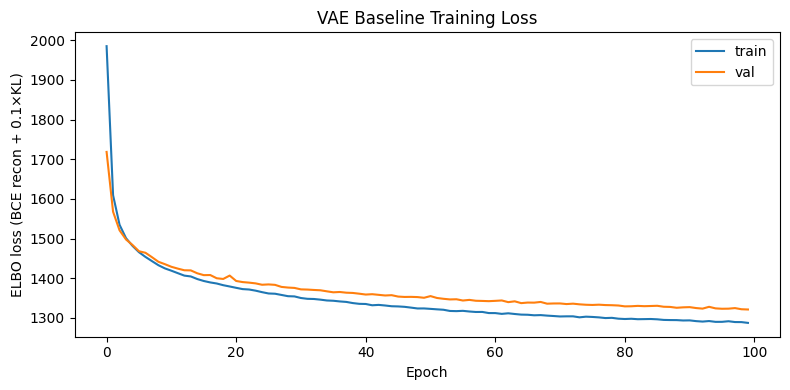

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = VAE(
    img_channels=IMG_CHANNELS,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    hidden_dims=HIDDEN_DIMS,
    latent_dim=LATENT_DIM,
).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR, betas=(ADAM_BETA1, 0.999))

train_losses, val_losses = [], []
train_recons, val_recons = [], []  # reconstruction component tracked separately for comparison

for epoch in range(EPOCHS):
    # --- train ---
    model.train()
    tr_total = tr_recon = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        x_hat, mu, logvar = model(batch)
        loss, recon, kl = vae_loss(batch, x_hat, mu, logvar)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        tr_total += loss.item()
        tr_recon += recon.item()
    train_losses.append(tr_total / len(train_loader))
    train_recons.append(tr_recon / len(train_loader))

    # --- validate ---
    model.eval()
    vl_total = vl_recon = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            x_hat, mu, logvar = model(batch)
            loss, recon, _ = vae_loss(batch, x_hat, mu, logvar)
            vl_total += loss.item()
            vl_recon += recon.item()
    val_losses.append(vl_total / len(val_loader))
    val_recons.append(vl_recon / len(val_loader))

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}  '
              f'train: {train_losses[-1]:.4f}  val: {val_losses[-1]:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('Epoch')
plt.ylabel(f'ELBO loss (BCE recon + {KL_WEIGHT}×KL)')
plt.title('VAE Baseline Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Reconstructions

Pass images through the full encoder â†’ reparameterise â†’ decoder pipeline and compare input vs output.

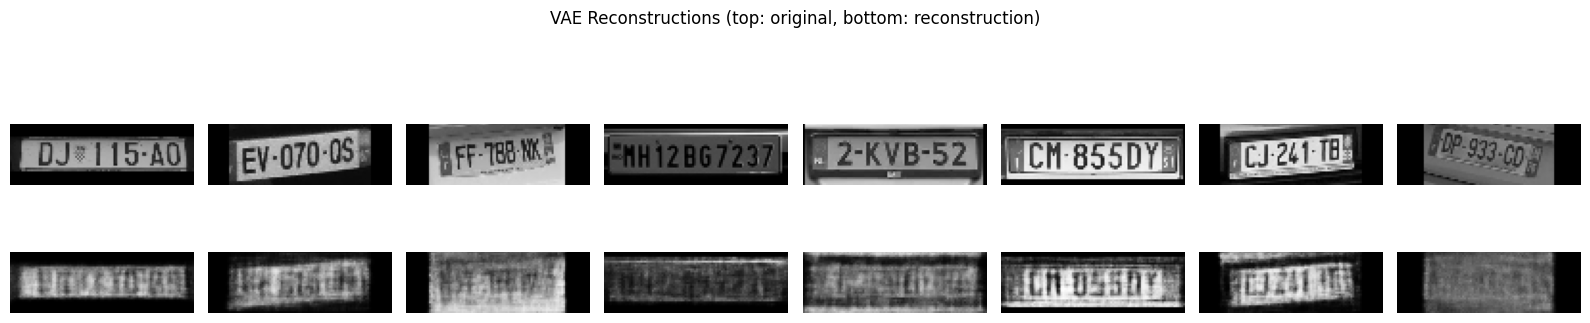

In [11]:
model.eval()
with torch.no_grad():
    batch = next(iter(val_loader)).to(device)
    x_hat, _, _ = model(batch)

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(16, 4))
for i in range(n_show):
    axes[0, i].imshow(batch[i].cpu().squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(x_hat[i].cpu().squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original',      fontsize=10)
axes[1, 0].set_ylabel('Reconstructed', fontsize=10)
plt.suptitle('VAE Reconstructions (top: original, bottom: reconstruction)')
plt.tight_layout()
plt.show()

## Reconstruction Error Analysis

Per-pixel absolute error heatmaps (brighter = larger error) alongside full-val-set
MAE and MSE. These pixel-level metrics are saved with the training curves so they
can be compared directly against DRAW in the final comparison cell.

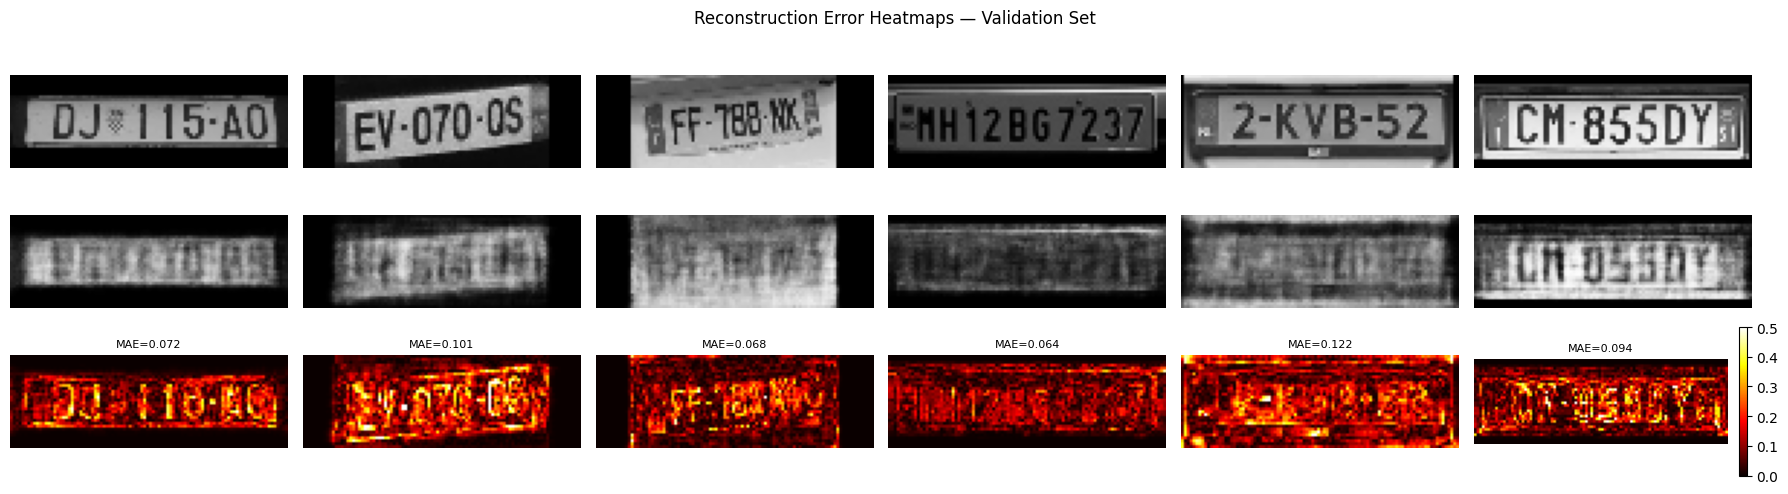

Val set  MAE: 0.0735  MSE: 0.0136  RMSE: 0.1166


In [12]:
model.eval()
with torch.no_grad():
    val_batch = next(iter(val_loader)).to(device)
    x_hat_vis, _, _ = model(val_batch)

n_show = 6
fig, axes = plt.subplots(3, n_show, figsize=(18, 5))
for i in range(n_show):
    orig  = val_batch[i].cpu().squeeze().numpy()
    recon = x_hat_vis[i].cpu().squeeze().numpy()
    err   = np.abs(orig - recon)
    axes[0, i].imshow(orig,  cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(recon, cmap='gray', vmin=0, vmax=1)
    im = axes[2, i].imshow(err, cmap='hot', vmin=0, vmax=0.5)
    axes[2, i].set_title(f'MAE={err.mean():.3f}', fontsize=8)
    for row in range(3):
        axes[row, i].axis('off')
axes[0, 0].set_ylabel('Original',      fontsize=10)
axes[1, 0].set_ylabel('Reconstruction', fontsize=10)
axes[2, 0].set_ylabel('|Error|',        fontsize=10)
plt.colorbar(im, ax=axes[2, -1], fraction=0.046, pad=0.04)
plt.suptitle('Reconstruction Error Heatmaps — Validation Set')
plt.tight_layout()
plt.show()

# Full-val-set pixel-level metrics
all_mae, all_mse = [], []
model.eval()
with torch.no_grad():
    for b in val_loader:
        b = b.to(device)
        xh, _, _ = model(b)
        diff = (b - xh).cpu().numpy()
        all_mae.append(np.abs(diff).mean(axis=(1, 2, 3)))
        all_mse.append((diff ** 2).mean(axis=(1, 2, 3)))
val_mae = float(np.concatenate(all_mae).mean())
val_mse = float(np.concatenate(all_mse).mean())
print(f'Val set  MAE: {val_mae:.4f}  MSE: {val_mse:.4f}  RMSE: {val_mse**0.5:.4f}')

## Generated Samples

Sample random latent vectors from the prior N(0, I) and decode them â€” these are plates the VAE imagines.

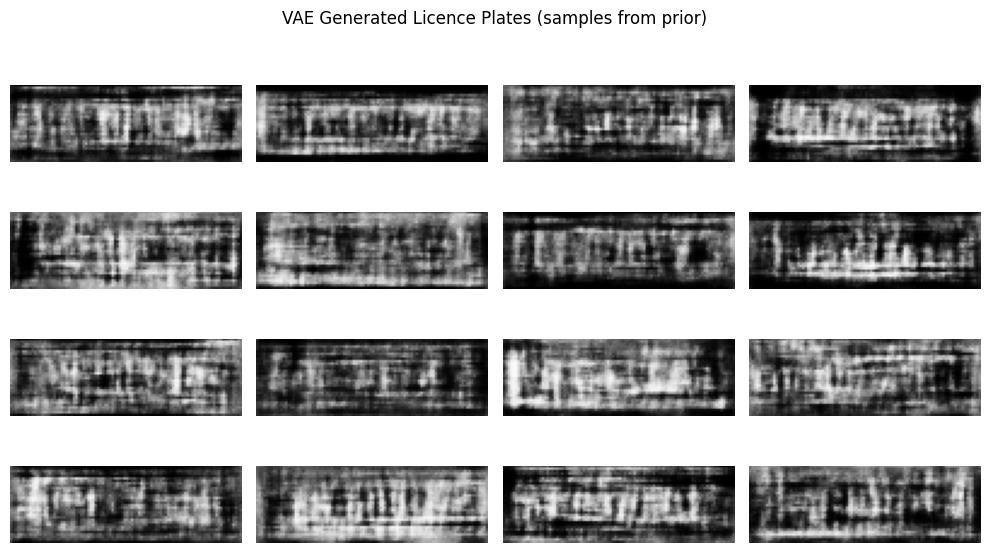

In [13]:
model.eval()
with torch.no_grad():
    generated = model.sample(16, device).cpu()

fig, axes = plt.subplots(4, 4, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.suptitle('VAE Generated Licence Plates (samples from prior)')
plt.tight_layout()
plt.show()

## Latent Space Interpolation

Interpolate linearly between the latent codes of two real plates.

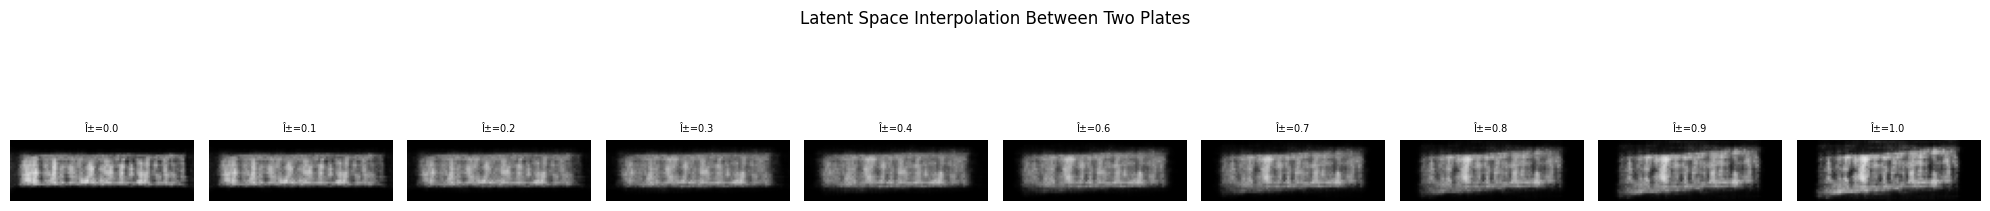

In [14]:
model.eval()
with torch.no_grad():
    batch = next(iter(val_loader)).to(device)
    mu, logvar = model.encoder(batch)
    z1, z2 = mu[0:1], mu[1:2]

    n_steps = 10
    alphas = torch.linspace(0, 1, n_steps, device=device)

    fig, axes = plt.subplots(1, n_steps, figsize=(20, 3))
    for i, alpha in enumerate(alphas):
        z = (1 - alpha) * z1 + alpha * z2
        img = model.decoder(z).cpu().squeeze().numpy()
        axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[i].axis('off')
        axes[i].set_title(f'Î±={alpha:.1f}', fontsize=7)

plt.suptitle('Latent Space Interpolation Between Two Plates')
plt.tight_layout()
plt.show()

## Notes & Expectations

### Alignment with (DRAW)
All controllable hyperparameters are matched to `draw_plates_rectangle2.py`
so that differences in results are attributable to architecture alone
(standard single-pass VAE vs. DRAW with iterative attention).

| Setting | Baseline VAE | DRAW (`draw_plates_rectangle2.py`) |
|---|---|---|
| Dataset | `train_96x32.npy` / `val_96x32.npy` | `license_plates_combined_96x32.npy` |
| Image size | 1 × 32 × 96 (grayscale) | 32 × 96 (grayscale) |
| Batch size | 32 | 32 |
| Optimiser | Adam, lr=1e-4, β1=0.5 | Adam, lr=1e-4, β1=0.5 |
| Gradient clipping | global norm 5.0 | global norm 5.0 |
| Epochs | 100 | 100 |
| Reconstruction loss | BCE (sum / batch size) | BCE (sum / batch size) |
| KL loss | 0.5×(sum over z, mean over batch) | 0.5×(sum over z, mean over batch)×T |
| KL weight | 0.1 | 0.1 |
| Latent dim | 64 | 64 (z\_size) |

### What differs (by design)
- **Architecture**: convolutional encoder + transposed-conv decoder with BatchNorm vs. LSTM-based recurrent encoder/decoder.
- **Inference**: single-pass vs. T=30 iterative refinement steps.
- **Attention**: none vs. read/write Gaussian filterbanks.

### Expectations
- Reconstructions should capture plate layout and character positions but may be blurry — a known limitation of single-pass VAEs with BCE loss.
- DRAW is expected to produce sharper reconstructions by attending iteratively to different plate regions.
- Generated samples from the prior may resemble plate structure but with illegible characters.

## VAE Baseline vs DRAW — Comparison

Saves this run's metrics to `vae_baseline_metrics.json` and plots training curves
side-by-side with the DRAW results from `license_plates_vae/draw_plates_results.npy`.
Run this cell after both models have been trained.

Saved → vae_baseline_metrics.json
DRAW results not found at 'license_plates_vae\\draw_plates_results.npy' — plotting VAE only.


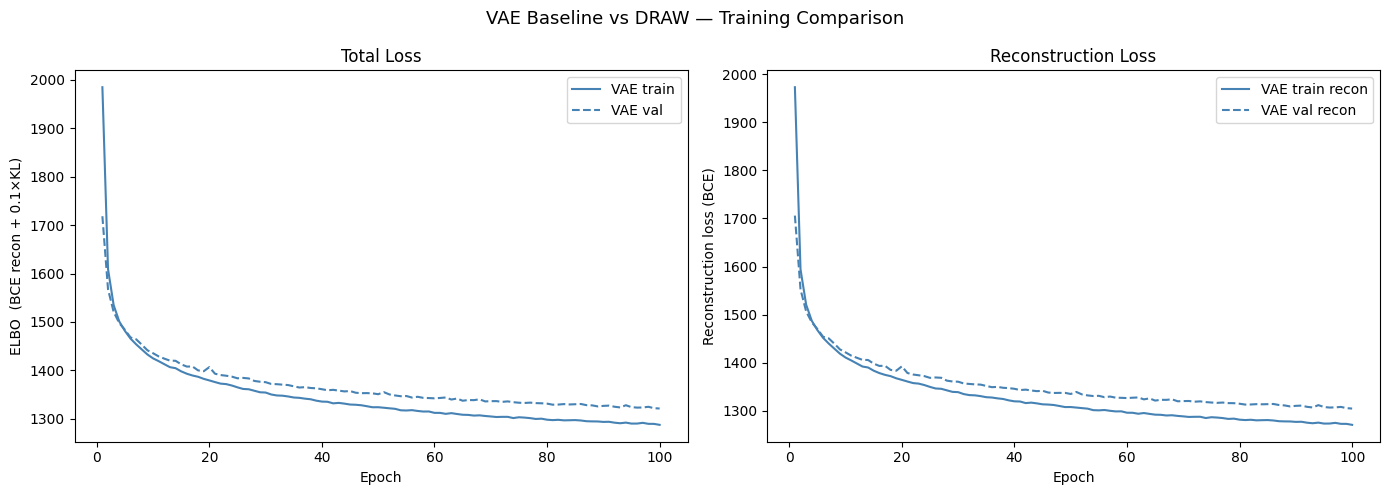


── Final metrics ───────────────────────────────
  VAE  train loss (epoch 100): 1287.3943
  VAE  val   loss (epoch 100): 1321.1449
  VAE  val   MAE:                  0.0735
  VAE  val   MSE:                  0.0136


In [15]:
import json

# ── Save VAE metrics ──────────────────────────────────────────────────────────
vae_metrics = {
    'model':        'VAE Baseline',
    'epochs':       EPOCHS,
    'lr':           LR,
    'latent_dim':   LATENT_DIM,
    'kl_weight':    KL_WEIGHT,
    'train_losses': train_losses,
    'val_losses':   val_losses,
    'train_recons': train_recons,
    'val_recons':   val_recons,
    'val_mae':      val_mae,
    'val_mse':      val_mse,
}
with open('vae_baseline_metrics.json', 'w') as fh:
    json.dump(vae_metrics, fh, indent=2)
print('Saved → vae_baseline_metrics.json')

# ── Load DRAW results ─────────────────────────────────────────────────────────
DRAW_RESULTS       = os.path.join('license_plates_vae', 'draw_plates_results.npy')
DRAW_DATASET_SIZE  = 1872   # license_plates_combined_96x32.npy
DRAW_ITERS_PER_EPOCH = DRAW_DATASET_SIZE // BATCH_SIZE   # = 58

draw_available = os.path.exists(DRAW_RESULTS)
if draw_available:
    draw_lx, draw_lz = np.load(DRAW_RESULTS, allow_pickle=True)
    n_iters          = len(draw_lx)
    n_epochs_draw    = n_iters // DRAW_ITERS_PER_EPOCH
    # Fold per-iteration losses into per-epoch means
    trim             = n_epochs_draw * DRAW_ITERS_PER_EPOCH
    draw_recon_epoch = draw_lx[:trim].reshape(n_epochs_draw, -1).mean(axis=1)
    draw_total_epoch = (draw_lx[:trim] + KL_WEIGHT * draw_lz[:trim]) \
                           .reshape(n_epochs_draw, -1).mean(axis=1)
    print(f'DRAW results: {n_iters} iters → {n_epochs_draw} epochs '
          f'({DRAW_ITERS_PER_EPOCH} iters/epoch)')
else:
    print(f'DRAW results not found at {DRAW_RESULTS!r} — plotting VAE only.')

# ── Comparison plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_vae  = range(1, len(train_losses) + 1)

# Left: total ELBO loss
axes[0].plot(epochs_vae, train_losses, color='steelblue', label='VAE train')
axes[0].plot(epochs_vae, val_losses,   color='steelblue', linestyle='--', label='VAE val')
if draw_available:
    axes[0].plot(range(1, n_epochs_draw + 1), draw_total_epoch,
                 color='tomato', label='DRAW train')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel(f'ELBO  (BCE recon + {KL_WEIGHT}×KL)')
axes[0].set_title('Total Loss')
axes[0].legend()

# Right: reconstruction loss only
axes[1].plot(epochs_vae, train_recons, color='steelblue', label='VAE train recon')
axes[1].plot(epochs_vae, val_recons,   color='steelblue', linestyle='--', label='VAE val recon')
if draw_available:
    axes[1].plot(range(1, n_epochs_draw + 1), draw_recon_epoch,
                 color='tomato', label='DRAW train recon (Lx)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction loss (BCE)')
axes[1].set_title('Reconstruction Loss')
axes[1].legend()

plt.suptitle('VAE Baseline vs DRAW — Training Comparison', fontsize=13)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n── Final metrics ───────────────────────────────')
print(f'  VAE  train loss (epoch {EPOCHS}): {train_losses[-1]:.4f}')
print(f'  VAE  val   loss (epoch {EPOCHS}): {val_losses[-1]:.4f}')
print(f'  VAE  val   MAE:                  {val_mae:.4f}')
print(f'  VAE  val   MSE:                  {val_mse:.4f}')
if draw_available:
    print(f'  DRAW train loss (epoch {n_epochs_draw}): {draw_total_epoch[-1]:.4f}')
    print(f'  DRAW train recon (Lx, epoch {n_epochs_draw}): {draw_recon_epoch[-1]:.4f}')